## Startup

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [18]:
# Defining time period & q_critical

experiment_start_date = "1970-01-01T00:00:00Z"
experiment_end_date = "2024-12-31T00:00:00Z"

q_critical = 500

hysets_id = "hysets_07DA001"
basin_size = 132572

In [30]:
# Loading in data

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "ERA5" / "ERA5-1970-2024"
forcing_path_ERA5.mkdir(exist_ok=True, parents=True)

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

# Load CSV discharge 07DA001
q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [31]:
# Filter q_obs to start & end date

start_date = pd.to_datetime(experiment_start_date.replace("Z", ""))
end_date = pd.to_datetime(experiment_end_date.replace("Z", ""))

q_obs = q_obs[
    (q_obs["Date"] >= start_date) &
    (q_obs["Date"] <= end_date)].copy()

q_obs.head()

,Date,discharge_m3s
14888,1999-01-01,104.0
14889,1999-01-02,103.0
14890,1999-01-03,101.0
14891,1999-01-04,103.0
14892,1999-01-05,105.0


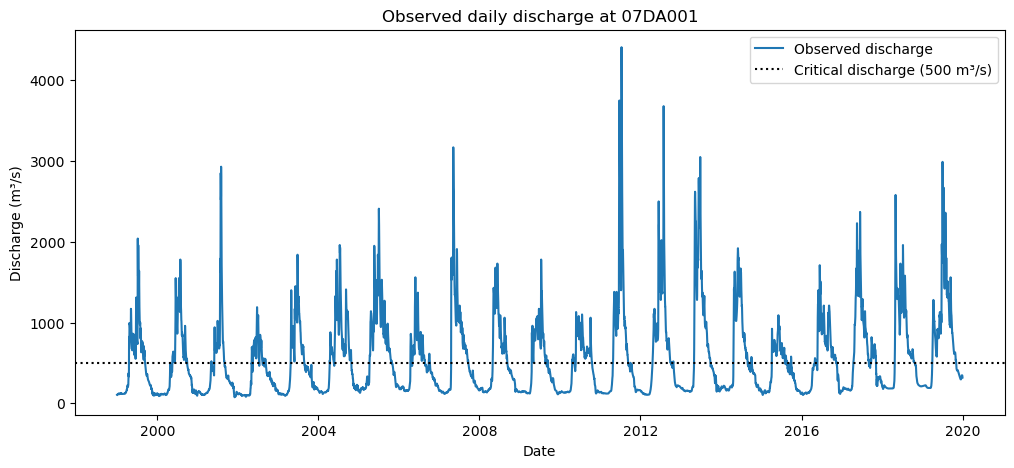

In [49]:
# Plot q_obs

plt.figure(figsize=(12, 5))
plt.plot(q_obs["Date"], q_obs["discharge_m3s"], label="Observed discharge")

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Observed daily discharge at 07DA001")

plt.axhline(y=q_critical, linestyle=":", label=f"Critical discharge ({q_critical} m³/s)", color='black')

plt.legend()
plt.show()

# Finding range

## Start of range (freshet)

### Idea 1: Q_critical 

In [33]:
# Create pd for identified critical dates

freshet_start_date = []

for year, group in q_obs.groupby(q_obs["Date"].dt.year):

    # Set start date to March 1
    start_date_algorithm = pd.to_datetime(f"{year}-03-01")
    season_data = group[group["Date"] >= start_date_algorithm].copy()
    
    # Identify first day where q > q_critical
    
    above_critical = season_data[
        season_data["discharge_m3s"] > q_critical]
    
    if len(above_critical) > 0:
        first_day = above_critical.iloc[0]
        
        freshet_start_date.append({
            "year": year,
            "first_above_critical_date": first_day["Date"],
            "discharge_m3s": first_day["discharge_m3s"]})

freshet_start_date = pd.DataFrame(freshet_start_date)

freshet_start_date

,year,first_above_critical_date,discharge_m3s
0,1999,1999-04-20,823.0
1,2000,2000-05-17,561.0
2,2001,2001-05-04,510.0
3,2002,2002-05-07,600.0
4,2003,2003-04-26,600.0
5,2004,2004-04-14,533.0
6,2005,2005-04-10,570.0
7,2006,2006-04-15,591.0
8,2007,2007-04-20,1200.0
9,2008,2008-05-01,520.0


In [50]:
def plot_discharge_for_year(q_obs, freshet_start_date, q_critical, selected_year):

    # Define plotting period to selected year
    start_date = f"{selected_year}-01-01"
    end_date = f"{selected_year}-12-31"

    # Adjust q_obs and freshet_start_date to fit plotting period
    q_obs_year = q_obs[
        (q_obs["Date"] >= start_date) &
        (q_obs["Date"] <= end_date)]

    freshet_year = freshet_start_date[
        (freshet_start_date["first_above_critical_date"] >= start_date) &
        (freshet_start_date["first_above_critical_date"] <= end_date)]

    # Start figure
    plt.figure(figsize=(12, 5))

    # Plot q_obs
    plt.plot(q_obs_year["Date"], q_obs_year["discharge_m3s"], label="Observed discharge")

    # Plot q_critical
    plt.axhline(y=q_critical, linestyle=":", label=f"Critical discharge ({q_critical} m³/s)", color="black")

    # Plot when q_critical is reached
    for date in freshet_year["first_above_critical_date"].dropna():
        plt.axvline(x=date, linestyle=':', color='orange', label='Start navigable season')

    plt.xlabel("Date")
    plt.ylabel("Discharge (m³/s)")
    plt.title(f"Observed daily discharge at 07DA001 in {selected_year}")

    plt.legend()
    plt.show()

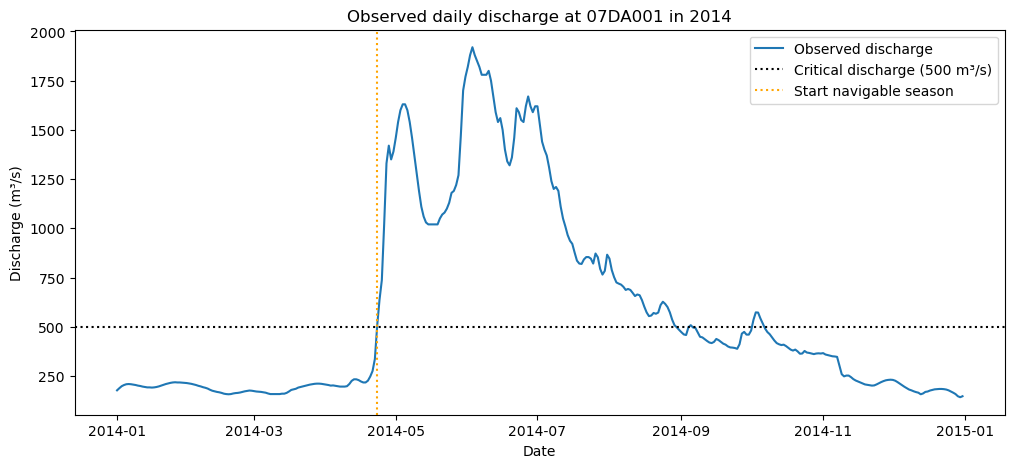

In [51]:
selected_year = 2014

plot_discharge_for_year(q_obs, freshet_start_date, q_critical, selected_year)

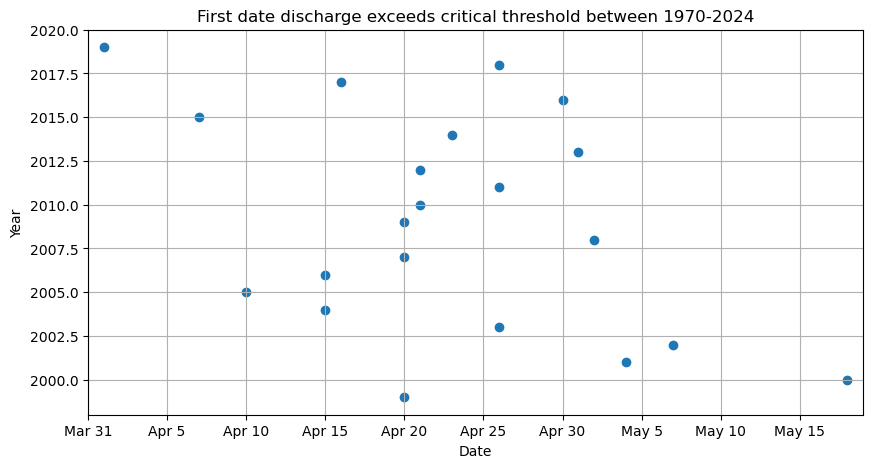

In [35]:
# Convert date to day of year
freshet_start_date["day_of_year"] = (freshet_start_date["first_above_critical_date"].dt.dayofyear)

# Make plot 
plt.figure(figsize=(10, 5))
plt.scatter(freshet_start_date["day_of_year"], freshet_start_date["year"], marker="o")

plt.xlabel("Date")
plt.ylabel("Year")
plt.title("First date discharge exceeds critical threshold between 1970-2024")
plt.grid(True)

# Convert day of year to day in months (on the axis)
plt.xticks(
    [60, 65, 70, 75, 80, 85, 90,
     95, 100, 105, 110, 115, 120,
     125, 130, 135, 140, 145, 150],
    ["Mar 1", "Mar 6", "Mar 11", "Mar 16", "Mar 21", "Mar 26", "Mar 31",
     "Apr 5", "Apr 10", "Apr 15", "Apr 20", "Apr 25", "Apr 30",
     "May 5", "May 10", "May 15", "May 20", "May 25", "May 30"],)

# Automate x-axis range to fit data
plt.xlim((freshet_start_date["day_of_year"].min()-1), (freshet_start_date["day_of_year"].max()+1))

plt.show()

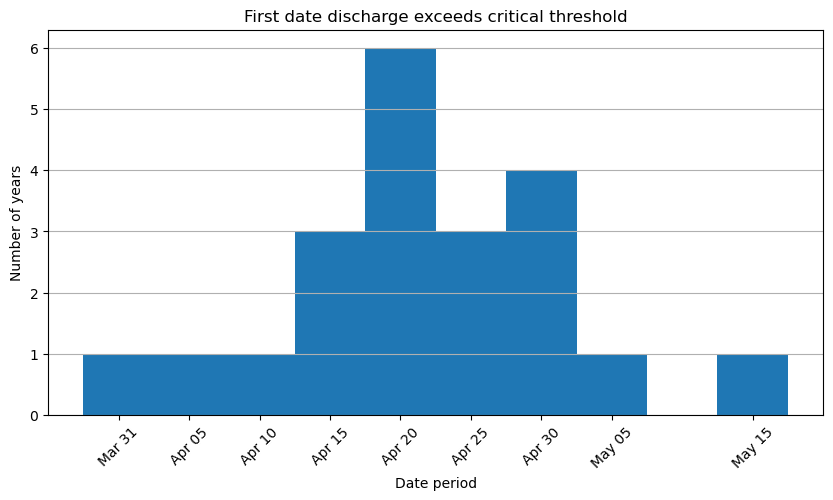

In [36]:
# Creating bar graph

# Choose bin size
bin_size = 5   # use 10 for 10-day periods

# Convert date to day of year
freshet_start_date["day_of_year"] = freshet_start_date["first_above_critical_date"].dt.dayofyear

# Create bins
freshet_start_date["date_bin"] = (freshet_start_date["day_of_year"] // bin_size) * bin_size

# Count how many years fall in each bin
freshet_counts = freshet_start_date.groupby("date_bin").size()

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(freshet_counts.index, freshet_counts.values, width=bin_size)

# Convert x-axis from day-of-year to calendar dates
tick_days = freshet_counts.index
tick_labels = [
    (pd.to_datetime("2001-01-01") + pd.to_timedelta(day - 1, unit="D")).strftime("%b %d")
    for day in tick_days]

plt.xticks(tick_days, tick_labels, rotation=45)

plt.xlabel("Date period")
plt.ylabel("Number of years")
plt.title("First date discharge exceeds critical threshold")
plt.grid(axis="y")

plt.show()

## End of range (river freeze-up)

### Idea 1: Critical when AFDD = x

AFDD is Accumulated Freeze Degree Days. It calculates the accumulative temperature under 0. 
Example: If 3 days have a mean temperature of -5 C per day, the AFDD would be 15. 

A study shows the LAR forms an ice sheet when AFDD reaches (approx) 50 degrees. https://www.iahr.org/library/infor?pid=26767 (Figure 6)

### Load ERA5-forcings & TAS data

In [37]:
# Generate ERA5 data

# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
#     directory=forcing_path_ERA5
# )

# Load ERA5 data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

In [38]:
# Exract tas file from Era5
tas_file = Path(ERA5_forcing.directory) / ERA5_forcing.filenames["tas"]

# Extract tas data from tas file
temp_data = xr.open_dataset(tas_file)["tas"]

# Convert to panda
temp_data = temp_data.to_series()
temp_data.index = pd.to_datetime(temp_data.index).tz_localize(None).normalize()

# Convert Kelvin to Celsius:
temp_data = temp_data - 273.15

# Create dataframe with Date, Temp & year as columns
temp_data = pd.DataFrame({
    "Date": temp_data.index,
    "Temp": temp_data.values,
    "year": temp_data.index.year})

In [39]:
AFDD_critical = 30
AFDD_critical_dates = []

start_year = start_date.year
end_year = end_date.year

for year in range(start_year, end_year + 1):

    # Set start date to 1 October
    year_data = temp_data[
        (temp_data["year"] == year) &
        (temp_data["Date"] >= pd.to_datetime(f"{year}-10-01"))]

    AFDD = 0
    
    # Isolate datasets of date & temperature data to each year 
    for i in range(len(year_data)):
        temp = year_data.iloc[i]["Temp"]
        date = year_data.iloc[i]["Date"]

        # Cumulative AFDD
        if temp < 0:
            AFDD += -temp

        # Append when AFDD is critical
        if AFDD >= AFDD_critical:
            AFDD_critical_dates.append({
                "year": year,
                "AFDD_critical_date": date,
                "AFDD": AFDD,
                "Temp": temp
            })

            break 

AFDD_critical_dates = pd.DataFrame(AFDD_critical_dates)

print(AFDD_critical_dates)

AFDD_critical_dates

year AFDD_critical_date       AFDD       Temp
0   1999         1999-11-13  30.221619  -1.962982
1   2000         2000-11-06  36.068024 -10.174591
2   2001         2001-10-30  30.810608  -1.809998
3   2002         2002-10-28  33.166534  -5.441467
4   2003         2003-11-01  34.717468  -7.344391
5   2004         2004-10-22  31.703094  -4.081665
6   2005         2005-11-12  30.604706  -5.060822
7   2006         2006-10-31  31.405975  -8.236450
8   2007         2007-11-14  33.085419  -3.336060
9   2008         2008-11-17  33.410309  -4.401947
10  2009         2009-10-12  31.520508  -7.005463
11  2010         2010-11-12  33.449890  -3.697540
12  2011         2011-11-08  31.026093  -2.132233
13  2012         2012-10-25  30.493774  -4.729126
14  2013         2013-11-05  34.175323 -10.181244
15  2014         2014-11-10  41.426453 -13.859253
16  2015         2015-11-17  33.754425  -3.863159
17  2016         2016-11-01  31.235596  -3.254517
18  2017         2017-11-03  42.753876 -14.209076
19  2018         2018-11-02  32.042358  -2.240051
20  2019         2019-10-29  41.300140 -11.644196

,year,AFDD_critical_date,AFDD,Temp
0,1999,1999-11-13,30.221619,-1.962982
1,2000,2000-11-06,36.068024,-10.174591
2,2001,2001-10-30,30.810608,-1.809998
3,2002,2002-10-28,33.166534,-5.441467
4,2003,2003-11-01,34.717468,-7.344391
5,2004,2004-10-22,31.703094,-4.081665
6,2005,2005-11-12,30.604706,-5.060822
7,2006,2006-10-31,31.405975,-8.236450
8,2007,2007-11-14,33.085419,-3.336060
9,2008,2008-11-17,33.410309,-4.401947


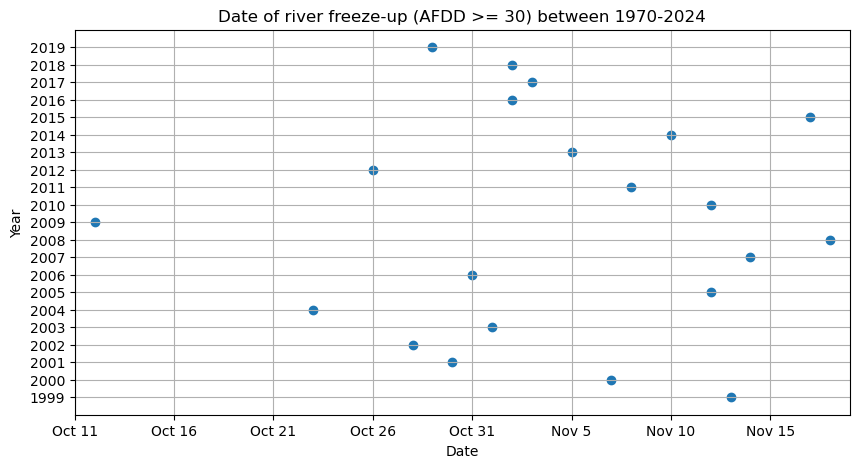

In [48]:
# Convert date to day of year
AFDD_critical_dates["day_of_year"] = (AFDD_critical_dates["AFDD_critical_date"].dt.dayofyear)

# Make plot 
plt.figure(figsize=(10, 5))
plt.scatter(AFDD_critical_dates["day_of_year"], AFDD_critical_dates["year"], marker="o")

plt.xlabel("Date")
plt.ylabel("Year")
plt.title(f"Date of river freeze-up (AFDD >= {AFDD_critical}) between 1970-2024")
plt.grid(True)

# Convert day of year to day in months (on the axis)
plt.xticks(
    [274, 279, 284, 289, 294, 299, 304,
     309, 314, 319, 324, 329, 334, 339,
     344, 349, 354, 359, 364, 366],
    ["Oct 1", "Oct 6", "Oct 11", "Oct 16", "Oct 21", "Oct 26", "Oct 31",
     "Nov 5", "Nov 10", "Nov 15", "Nov 20", "Nov 25", "Nov 30", "Dec 5",
     "Dec 10", "Dec 15", "Dec 20", "Dec 25", "Dec 30", "Dec 31"],)

# Prevent y-axis from showing decimal years
plt.yticks(range(start_year, end_year + 1))

# Automate x-axis range to fit data
plt.xlim((AFDD_critical_dates["day_of_year"].min()-1), (AFDD_critical_dates["day_of_year"].max()+1))

plt.show()

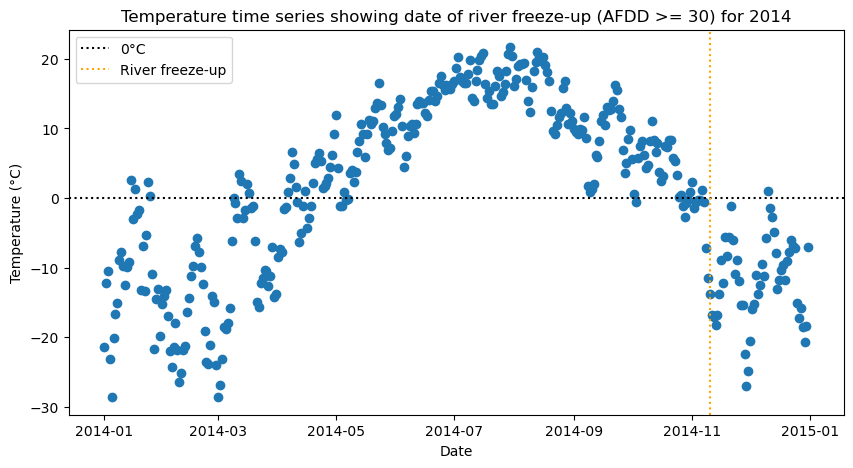

In [47]:
# Plot temp for 1 year for fun:
selected_year = 2014
year_data = temp_data[temp_data["year"] == selected_year]

plt.figure(figsize=(10, 5))
plt.title(f"Temperature time series showing date of river freeze-up (AFDD >= {AFDD_critical}) for 2014")
plt.scatter(year_data["Date"], year_data["Temp"], marker="o")
plt.axhline(y=0, linestyle=":", color="black", label="0°C")

# Extract & plot critical AFDD date for selected year
AFDD_critical_date = AFDD_critical_dates.loc[AFDD_critical_dates["year"] == selected_year, "AFDD_critical_date"].iloc[0]
plt.axvline(x=AFDD_critical_date, linestyle=":", color="orange", label="River freeze-up")

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

### Idea 2: Critical when q_critical < 500